# **Customer Personality Analysis: Marketing Campaign Report**
### by Darren Axellian Hartono

G12: "Darren and Co."

Group members:
- Muhammad Daffa
- Jeevani Anintya Putri
- Edward Budiman

In [ ]:
# Install packages
install.packages("tidyverse")
install.packages("dplyr")
install.packages("broom")
install.packages("glmnet")

In [2]:
# Libraries used
suppressWarnings(
  suppressPackageStartupMessages({
    library(tidyverse)
    library(broom)
    library(glmnet)
  })
)

In [4]:
# Dataset taken from https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis?resource=download 
url <- "https://raw.githubusercontent.com/drrnaxl/STAT-301-Project/refs/heads/main/marketing_campaign.csv"
cpa <- read.delim(url)

## (1) Data Description

(a) The dataset contains marketing campaign data for 2,240 customers and includes 29 variables distributed as demographic variables, purchasing behaviour, and campaign responses.

In [5]:
# Number of observations & variables
glimpse(cpa)

Rows: 2,240
Columns: 29
$ ID                  <int> 5524, 2174, 4141, 6182, 5324, 7446, 965, 6177, 485…
$ Year_Birth          <int> 1957, 1954, 1965, 1984, 1981, 1967, 1971, 1985, 19…
$ Education           <chr> "Graduation", "Graduation", "Graduation", "Graduat…
$ Marital_Status      <chr> "Single", "Single", "Together", "Together", "Marri…
$ Income              <int> 58138, 46344, 71613, 26646, 58293, 62513, 55635, 3…
$ Kidhome             <int> 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,…
$ Teenhome            <int> 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,…
$ Dt_Customer         <chr> "04-09-2012", "08-03-2014", "21-08-2013", "10-02-2…
$ Recency             <int> 58, 38, 26, 26, 94, 16, 34, 32, 19, 68, 11, 59, 82…
$ MntWines            <int> 635, 11, 426, 11, 173, 520, 235, 76, 14, 28, 5, 6,…
$ MntFruits           <int> 88, 1, 49, 4, 43, 42, 65, 10, 0, 0, 5, 16, 61, 2, …
$ MntMeatProducts     <int> 546, 6, 127, 20, 118, 98, 164, 56, 24, 6, 6, 11, 4…
$ MntFishProduct

(b) Run code below for table:

In [6]:
#Table
data.frame(Type = sapply(cpa, class))

,Type
,<chr>
ID,integer
Year_Birth,integer
Education,character
Marital_Status,character
Income,integer
Kidhome,integer
Teenhome,integer
Dt_Customer,character
Recency,integer



(c) It can be assumed that the data is collected from surveys and data provided by membership subscription.

(d) Dataset is provided by Dr. Omar Romero-Hernandez. Not much else is known.
 

## (2) Question

(a) Which variables are most associated with the number of store purchases (NumStorePurchases)?

(b) I focus primarily on prediction, as the main goal is to identify which variables are most useful for predicting the response. Since the dataset is observational, the results should be interpreted as predictive associations rather than causal relationships.

(c) The response variable is "NumStorePurchases". This variable measures the number of purchases done at the store front.

(d) I anticipate that variables related to income and customer behaviour will be among the most important predictors. In particular, Income, Recency, NumDealsPurchases, and NumWebVisitsMonth seem likely to be informative because they reflect purchasing power, recent engagement, discount-seeking behaviour, and overall interaction with the company. 

(e) Other variables will be used as control variables to account for demographic and household differences. These include Education and Marital Status, as these variables may reflect socioeconomic and lifestyle differences that influence spending behaviour.
  
The remaining variables are not included in the primary model because some are: 
- Identifiers or administrative fields: covariates such as ID and Dt_Customer do not provide meaningful explanatory value for predicting store purchases.
- Promotions related: covariates such as AcceptedCmp1 to AcceptedCmp5 because the analysis is intended to focus on broader demographic, household, and customer-engagement characteristics rather than campaign-specific indicators.
- Has no description on what they represent: covariates such as Z_CostContact, Z_Revenue, making them difficult to interpret reliably.
- Too closely related to the response variable: covariates such as NumWebPurchases, NumCatalogPurchases, and the product spending variables: MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds because they reflect purchasing behaviour that overlaps strongly with NumStorePurchases.

Including these variables could make the model less interpretable, since it would rely on other direct measures of customer purchasing activity rather than broader customer characteristics. Therefore, the analysis focuses on a more parsimonious set of demographic, household, and engagement-related predictors.

## (3) Exploratory Data Analysis and Visualization

### (a) Dataset loading

In [7]:
# Dataset taken from https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis?resource=download 
url <- "https://raw.githubusercontent.com/drrnaxl/STAT-301-Project/refs/heads/main/marketing_campaign.csv"
cpa <- read.delim(url)

### (b) Data cleaning and wrangling

Income is log transformed due to skewness in the distribution.

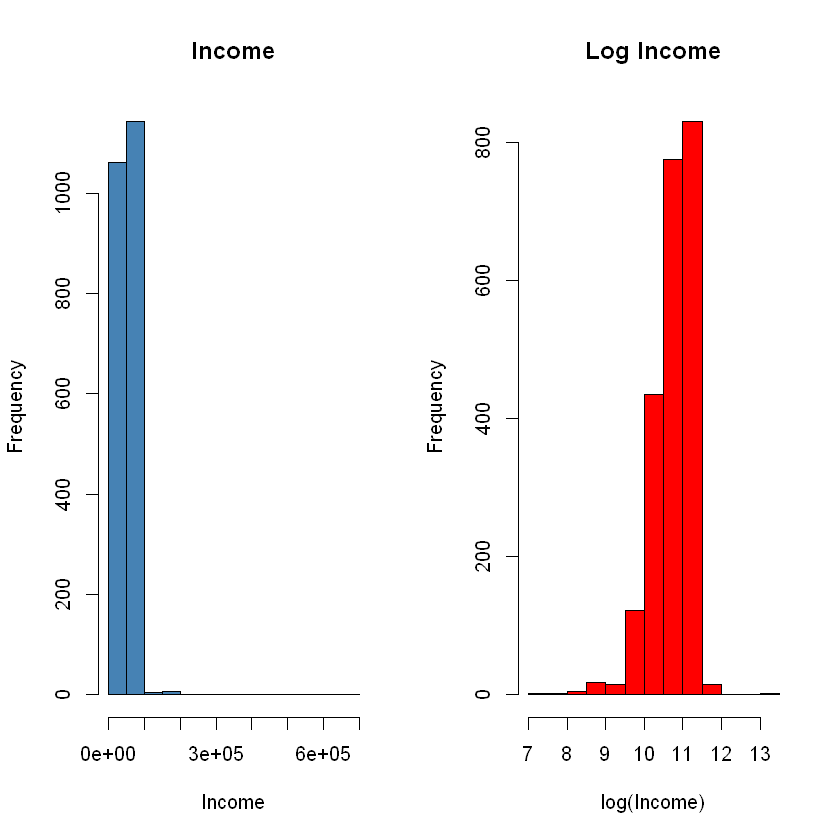

In [8]:
# Skewness
par(mfrow = c(1,2))

hist(cpa$Income,
     main = "Income",
     xlab = "Income",
     col = "steelblue")

hist(log(cpa$Income),
     main = "Log Income",
     xlab = "log(Income)",
     col = "red")

par(mfrow = c(1,1))

Since Marital_Status has many levels, it could get too complicated to include them all. Thus, I reduced the levels down to two: "In Relationship" if Married or Together, and "Single" otherwise.

In [73]:
# Cleaning and Wrangling
cpa_cleaned <- cpa |> 
    filter(
        !is.na(Income)
        ) |>
    mutate(
        Age = 2026 - Year_Birth,
        Education = as.factor(Education),
        Relationship_Status = as.factor(ifelse(Marital_Status %in% c("Married", "Together"),
                                "In Relationship",
                                "Single")),
        logIncome = log(Income),
    ) |>
select(ID, Age, Education, Relationship_Status, logIncome, Kidhome, Teenhome, Recency, NumDealsPurchases, NumStorePurchases, NumWebVisitsMonth)
head(cpa_cleaned)

,ID,Age,Education,Relationship_Status,logIncome,Kidhome,Teenhome,Recency,NumDealsPurchases,NumStorePurchases,NumWebVisitsMonth
,<int>,<dbl>,<fct>,<fct>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>
1,5524,69,Graduation,Single,10.97057,0,0,58,3,4,7
2,2174,72,Graduation,Single,10.74385,1,1,38,2,2,5
3,4141,61,Graduation,In Relationship,11.17903,0,0,26,1,10,4
4,6182,42,Graduation,In Relationship,10.19039,1,0,26,2,4,6
5,5324,45,PhD,In Relationship,10.97324,1,0,94,5,6,5
6,7446,59,Master,In Relationship,11.04313,0,1,16,2,10,6


### (c) Missing Values
There are 24 missing values from Income, with the proportion being less than 0.011. So, there are no variables with a large amount of missing data.

In [65]:
# Missing values
missing_values <- colSums(is.na(cpa))

# Missing proportions
missing_prop <- colMeans(is.na(cpa))

# Missing data table
data.frame(missing_values, missing_prop) |> filter(missing_values > 0)

,missing_values,missing_prop
,<dbl>,<dbl>
Income,24,0.01071429


### (d) Class Imbalance
There is no severe class imbalance among the main categories in the dataset, though some minor imbalance exists. In Education, the largest group is Graduation, which represents about 50.3% of customers, while the rest are distributed across PhD (21.7%), Master (16.5%), 2n Cycle (9.1%), and Basic (2.4%).

For Relationship_Status, after regrouping to two levels, the largest group is In Relationship with approximately 64.53% of customers, and 35.47% Single. There is a class imbalance as more than half of the customers are in a relationship, but not severe.

Thus, the dataset does not exhibit severe class imbalance among the main categories.

In [70]:
# Class Imbalance Check
cpa_cleaned |> count(Relationship_Status) |> mutate(percentage = n / sum(n) * 100) 
cpa_cleaned |> count(Education) |> mutate(percentage = n / sum(n) * 100) 


Relationship_Status,n,percentage
<fct>,<int>,<dbl>
In Relationship,1430,64.53069
Single,786,35.46931


Education,n,percentage
<fct>,<int>,<dbl>
2n Cycle,200,9.025271
Basic,54,2.436823
Graduation,1116,50.361011
Master,365,16.471119
PhD,481,21.705776


### (e) Visualization 
To explore whether demographics and family structure influence number of store purchases, I propose a faceted jittered scatterplot of NumStorePurchases against logIncome, with points coloured by Education and panels separated by Relationship_Status. This plot is relevant because it allows me to visually assess how store purchases vary with income while also exploring whether education and relationship status may contribute meaningful patterns in the response.

`geom_smooth()` using formula = 'y ~ x'


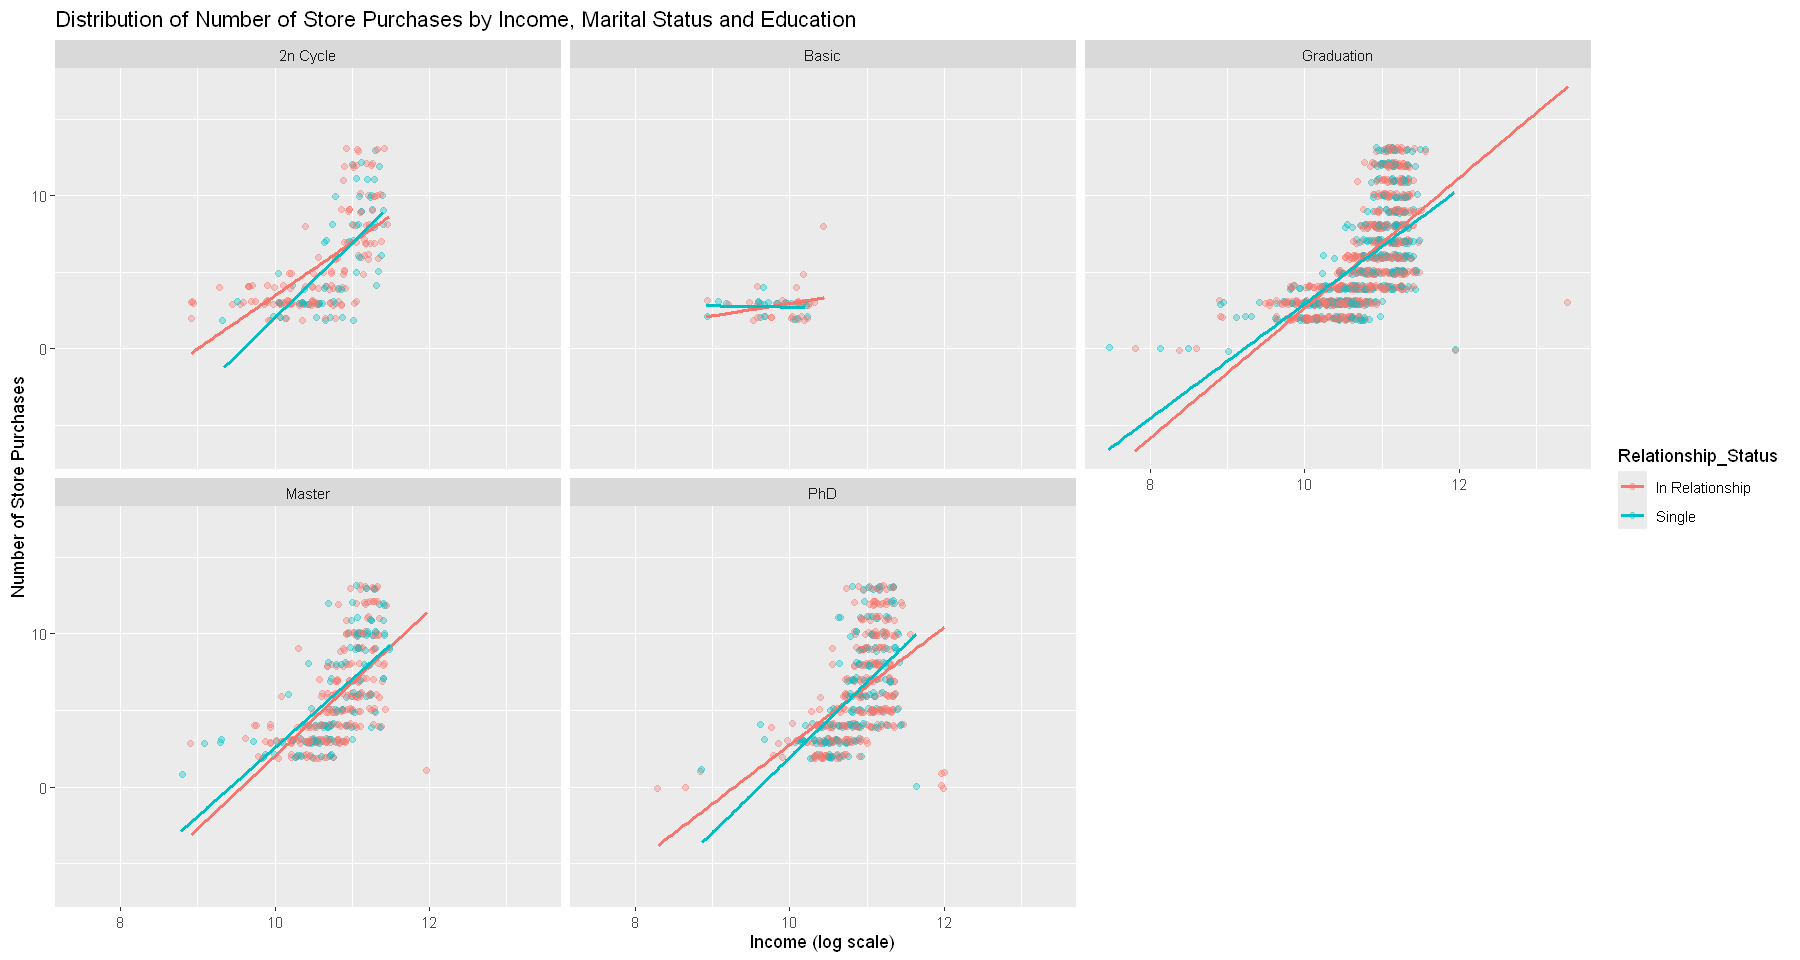

In [71]:
# Adjust accordingly
options(repr.plot.width = 15, repr.plot.height = 8)

# EDA Plot
cpa_cleaned |> 
 ggplot(aes(x = logIncome, y = NumStorePurchases, color = Relationship_Status)) +
  geom_jitter(alpha = 0.35, width = 0.03, height = 0.15) +
  facet_wrap(~Education) +
  geom_smooth(method = "lm", se = FALSE) +
  labs(
    title = "Distribution of Number of Store Purchases by Income, Marital Status and Education",
    x = "Income (log scale)",
    y = "Number of Store Purchases"
  )

### (f) AI Use Disclosure
AI tools (ChatGPT) were used to assist with debugging R code and improving wording of explanations. All analysis, interpretation, and visualization design were completed independently.

## Methods, Plan, and Analysis of Store Purchases

### Reviewed Question
Which variables in the customer personality dataset are most useful for predicting the number of store purchases (NumStorePurchases)?

### (1) Methods and Plans
#### (a) Method Proposal
I propose using a Poisson LASSO regression model to address this question. This is appropriate because NumStorePurchases is a non-negative count variable, and the Poisson model is designed for count responses. Adding the LASSO penalty allows variable selection from a larger set of candidate predictors, producing a more interpretable and parsimonious predictive model. I chose this method because it matches the count nature of the response while also helping determine which variables in the dataset are most useful for prediction.

#### (b) Assumptions and Limitations
The Poisson LASSO model assumes that observations are independent and that the predictors have been appropriately prepared, including handling missing values and converting categorical variables into indicator variables when needed. It also assumes that the response variable is a count and that its expected value is related to the predictors through a log link. In addition, it assumes that the conditional variance is approximately equal to the conditional mean.

One limitation of LASSO is that when predictors are highly correlated, the method may select one variable and exclude another similar one, so the selected model may be somewhat unstable. A further limitation is that categorical variables are represented through dummy variables, so LASSO may retain only some levels of a factor while shrinking others to zero, which can make interpretation less straightforward. Another limitation is that the selected coefficients are primarily useful for prediction and variable screening, and should not be interpreted as causal effects. If the count response exhibits substantial overdispersion, a Poisson-based model may not fit as well. Any relationships identified should be interpreted as predictive associations rather than evidence of causation.

### (2) Computational Code and Output
#### (a) Implementation of Proposed Method


In [74]:
# Check if Overdispersion
cpa_logistic_model <- glm(
                        NumStorePurchases ~ . -ID,
                        data = cpa_cleaned,
                        family = poisson()
                    )

deviance(fit) / df.residual(fit)


[1] 0.819132

To assess the Poisson variance assumption, I checked the ratio of residual deviance to residual degrees of freedom, which was approximately 0.819. Since this value is not greater than 1 and is reasonably close to 1, there is no strong evidence of overdispersion in the fitted Poisson model.

In [ ]:
set.seed(301)

# Data splitting
cpa_train <- cpa_cleaned |> slice_sample(prop = 0.7) |> drop_na()
cpa_test <- cpa_cleaned |> anti_join(cpa_train, by = "ID") |> drop_na()

cpa_train <- cpa_train |> select(-ID)
cpa_test <- cpa_test |> select(-ID)

# Create model matrix
x_train <- model.matrix(NumStorePurchases ~ ., data = cpa_train)[, -1]
y_train <- cpa_train$NumStorePurchases

x_test <- model.matrix(NumStorePurchases ~ ., data = cpa_test)[, -1]
y_test <- cpa_test$NumStorePurchases

# Cross-validated Poisson LASSO
cv_lasso <- cv.glmnet(
  x = x_train, y = y_train,
  family = "poisson",
  alpha = 1,
  nfolds = 10
)

# Fit model at lambda.min
lasso_fit <- glmnet(
  x = x_train, y = y_train,
  family = "poisson",
  alpha = 1,
  lambda = cv_lasso$lambda.min
)

# Extract nonzero coefficients
selected_table <- as.matrix(coef(lasso_fit)) |>
  as.data.frame() |> 
  tibble::rownames_to_column("term") |>
  rename(coefficient = s0) |>
  filter(coefficient != 0)

selected_table

,observed,predicted
,<int>,<dbl>
1,4,7.153817
2,6,6.383113
3,8,7.362550
4,9,7.752027
5,5,4.820477
6,0,2.352795


term,coefficient
<chr>,<dbl>
(Intercept),-4.349838475
Age,-0.001744591
logIncome,0.582676010
Kidhome,-0.358762697
Teenhome,-0.045682184
NumDealsPurchases,0.075029866
NumWebVisitsMonth,-0.025645565


#### (b) Visualization Result

In [69]:
selected_table |>
  mutate(coefficient = round(coefficient, 4))

term,coefficient
<chr>,<dbl>
(Intercept),-4.8841
Age,-0.0014
EducationPhD,-0.0165
logIncome,0.6255
Kidhome,-0.3482
Teenhome,-0.0384
NumDealsPurchases,0.0572
NumWebVisitsMonth,-0.0095


##### (c) Conclusion

The Poisson LASSO model selected a subset of predictors as most useful for predicting NumStorePurchases, including logIncome, Kidhome, Teenhome, NumDealsPurchases, NumWebVisitsMonth, Age, and the PhD level of education. Among these, logIncome and NumDealsPurchases had positive coefficients, while variables such as Kidhome and NumWebVisitsMonth had negative coefficients, suggesting that both customer characteristics and engagement patterns contribute to predicting store purchases. Since categorical variables were represented through indicator variables, LASSO selected the PhD level of education relative to the reference category while shrinking the other education levels to zero. Overall, the results suggest that a relatively small set of demographic, household, and engagement-related variables can provide useful predictive information about store-purchase behaviour, though these should be interpreted as predictive associations rather than causal effects.